In [6]:
import os
import json
import torch
import matplotlib.pyplot as plt
from posixpath import join
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torch_geometric.loader import DataLoader

from EGAT import EGAT_model
import StrokeGraphDataset_class


RUN_DIRECTORY = "./checkpoints/40.0,2.0,23,19,2/run_20260325_033122" 

BATCHES_DIRECTORY = "./batches/" + RUN_DIRECTORY["./checkpoints/".__len__():RUN_DIRECTORY.find("run_")-1]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Використовується пристрій: {device}")

Використовується пристрій: cuda


In [7]:
def read_config(path: str):
    with open(path, 'r') as f:
        return json.load(f)

configs = read_config(join(RUN_DIRECTORY, 'config.json'))
file_lists = read_config(join(RUN_DIRECTORY, 'file_list.json'))

test_files = file_lists.get("file test list:", [])
test_files_with_aug = list(test_files)
test_aug_only_files = []

for f in test_files:
    base = f.replace('_proc.pt', '')
    test_aug_only_files.extend([
        af for af in os.listdir(BATCHES_DIRECTORY) 
        if (af.startswith('aug') or af.startswith('sep')) 
        and af.endswith('_proc.pt') 
        and base in af
    ])

test_files_with_aug.extend(test_aug_only_files)

if configs["out_channels"] == 2:
    class_names = ["Non-Text", "Text"]
elif configs["out_channels"] == 5:
    class_names = ["Text", "Table", "Formula", "Diagram", "Other"]
else:
    class_names = [f"Class {i}" for i in range(configs["out_channels"])]

print(f"Кількість оригінальних тестових файлів: {len(test_files)}")
print(f"Кількість файлів з аугментацією (оригінали + ауг): {len(test_files_with_aug)}")

Кількість оригінальних тестових файлів: 95
Кількість файлів з аугментацією (оригінали + ауг): 769


In [8]:
batch_size = configs.get("batch_size", 4)

temp_dataset = StrokeGraphDataset_class.StrokeGraphDataset(BATCHES_DIRECTORY, test_files[:1])
temp_loader = DataLoader(temp_dataset, batch_size=1, shuffle=False)
sample_batch = next(iter(temp_loader))

model = EGAT_model(
    in_channels=sample_batch.x.size(1),
    hidden_channels=configs["hidden_channels"],
    out_channels=configs["out_channels"],
    edge_dim=sample_batch.edge_attr.size(1),
    heads=configs["heads"],
    num_hidden_layers=configs["hidden_layers"],
    dropout=configs["dropout"]
).to(device)

model_path = join(RUN_DIRECTORY, 'final_model.pt')
model.load_model(model_path, device)
model.eval()

print("Модель успішно завантажена та переведена в режим оцінки (eval)!")
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Кількість параметрів у моделі: {total_params:,}")
    return total_params

def measure_flops(model, data):
    model.eval()
    inputs = (data.x, data.edge_index, data.edge_attr)
    
    flops = FlopCountAnalysis(model, inputs)
    
    flops.unsupported_ops_warnings(False)
    
    total_flops = flops.total()
    print(f"FLOPs для даного графа: {total_flops / 1e6:.2f} MegaFLOPs (MFLOPs)")
    
    return total_flops

count_parameters(model)

  missing keys: ['layers.0.edge_gru.weight_ih', 'layers.0.edge_gru.weight_hh', 'layers.0.edge_gru.bias_ih', 'layers.0.edge_gru.bias_hh', 'layers.1.edge_gru.weight_ih', 'layers.1.edge_gru.weight_hh', 'layers.1.edge_gru.bias_ih', 'layers.1.edge_gru.bias_hh', 'layers.2.edge_gru.weight_ih', 'layers.2.edge_gru.weight_hh', 'layers.2.edge_gru.bias_ih', 'layers.2.edge_gru.bias_hh']
  unexpected keys: ['layers.0.lin_node.weight', 'layers.0.lin_node.bias', 'layers.0.lin_edge.weight', 'layers.0.lin_edge.bias', 'layers.0.lin_reduce.weight', 'layers.0.lin_reduce.bias', 'layers.1.lin_node.weight', 'layers.1.lin_node.bias', 'layers.1.lin_edge.weight', 'layers.1.lin_edge.bias', 'layers.1.lin_reduce.weight', 'layers.1.lin_reduce.bias', 'layers.2.lin_node.weight', 'layers.2.lin_node.bias', 'layers.2.lin_edge.weight', 'layers.2.lin_edge.bias', 'layers.2.lin_reduce.weight', 'layers.2.lin_reduce.bias']
Модель успішно завантажена та переведена в режим оцінки (eval)!
Кількість параметрів у моделі: 1,378,983


1378983

In [9]:
import torch.nn.functional as F
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    matthews_corrcoef, hamming_loss, jaccard_score, log_loss, roc_auc_score
)

def evaluate_and_plot(model, dataloader, device, class_names, title_prefix="Test"):
    """Проганяє дані через модель, виводить розширений звіт метрик і малює Confusion Matrix inline."""
    all_preds = []
    all_labels = []
    all_probs = []

    once_ev_flops=True
    with torch.no_grad():
        for data in dataloader:
            data = data.to(device)
            if once_ev_flops:
                measure_flops(model, data)
                once_ev_flops = False
            out = model(data.x, data.edge_index, data.edge_attr)
            
            probs = F.softmax(out, dim=1)
            pred = out.argmax(dim=1)
            
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    print(f"\n{'='*60}")
    print(f"--- РОЗШИРЕНІ МЕТРИКИ: {title_prefix.upper()} ---")
    print(f"{'='*60}")

    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0)
    print("1. Звіт класифікації (Classification Report):\n", report)

    print("2. Додаткові метрики якості:")
    print(f"   - Accuracy (Загальна точність):          {accuracy_score(all_labels, all_preds):.4f}")
    print(f"   - Balanced Accuracy (Збалансована):      {balanced_accuracy_score(all_labels, all_preds):.4f}")
    print(f"   - Cohen's Kappa (Узгодженість):          {cohen_kappa_score(all_labels, all_preds):.4f}")
    print(f"   - Matthews Corrcoef (MCC)*:              {matthews_corrcoef(all_labels, all_preds):.4f}")
    print(f"   - Jaccard Score (Macro):                 {jaccard_score(all_labels, all_preds, average='macro'):.4f}")
    print(f"   - Hamming Loss (Частка помилок):         {hamming_loss(all_labels, all_preds):.4f}")
    
    print("\n3. Метрики на основі ймовірностей (Probabilities):")
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        print(f"   - ROC AUC (Macro OVR):                   {auc:.4f}")
    except Exception as e:
        print(f"   - ROC AUC: Неможливо обчислити ({e})")
        
    try:
        ll = log_loss(all_labels, all_probs)
        print(f"   - Log Loss (Крос-ентропія):              {ll:.4f}")
    except Exception as e:
        print(f"   - Log Loss: Неможливо обчислити ({e})")

    print("\n4. Confusion Matrix (Матриця помилок):")
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
    
    plt.title(f'Confusion Matrix ({title_prefix})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    #* MCC (Matthews Correlation Coefficient) вважається найкращою метрикою для незбалансованих класів (від -1 до +1).

=== Запуск тестування на оригінальних файлах ===
FLOPs для даного графа: 30685.20 MegaFLOPs (MFLOPs)

--- РОЗШИРЕНІ МЕТРИКИ: ORIGINAL FILES ---
1. Звіт класифікації (Classification Report):
               precision    recall  f1-score   support

    Non-Text     0.5351    0.8985    0.6707      7750
        Text     0.9635    0.7746    0.8588     26837

    accuracy                         0.8023     34587
   macro avg     0.7493    0.8365    0.7647     34587
weighted avg     0.8675    0.8023    0.8166     34587

2. Додаткові метрики якості:
   - Accuracy (Загальна точність):          0.8023
   - Balanced Accuracy (Збалансована):      0.8365
   - Cohen's Kappa (Узгодженість):          0.5421
   - Matthews Corrcoef (MCC)*:              0.5793
   - Jaccard Score (Macro):                 0.6285
   - Hamming Loss (Частка помилок):         0.1977

3. Метрики на основі ймовірностей (Probabilities):
   - ROC AUC: Неможливо обчислити (y should be a 1d array, got an array of shape (34587, 2) ins

c:\Users\ivan\.conda\envs\Diploma\Lib\site-packages\sklearn\metrics\_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


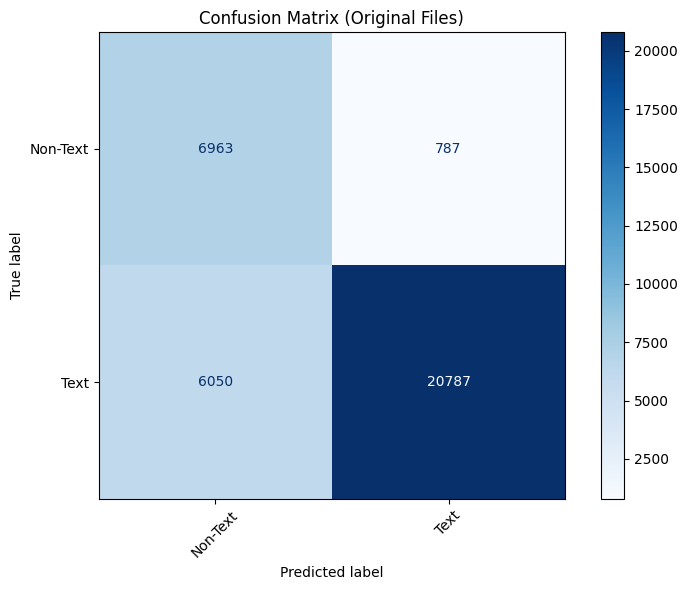

In [10]:
print("=== Запуск тестування на оригінальних файлах ===")
test_dataset = StrokeGraphDataset_class.StrokeGraphDataset(BATCHES_DIRECTORY, test_files)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

evaluate_and_plot(model, test_loader, device, class_names, title_prefix="Original Files")

=== Запуск тестування на файлах з аугментацією ===
FLOPs для даного графа: 30685.20 MegaFLOPs (MFLOPs)

--- РОЗШИРЕНІ МЕТРИКИ: WITH AUGMENTATION ---
1. Звіт класифікації (Classification Report):
               precision    recall  f1-score   support

    Non-Text     0.5724    0.8810    0.6940     38457
        Text     0.9434    0.7507    0.8361    101511

    accuracy                         0.7865    139968
   macro avg     0.7579    0.8159    0.7650    139968
weighted avg     0.8414    0.7865    0.7970    139968

2. Додаткові метрики якості:
   - Accuracy (Загальна точність):          0.7865
   - Balanced Accuracy (Збалансована):      0.8159
   - Cohen's Kappa (Узгодженість):          0.5411
   - Matthews Corrcoef (MCC)*:              0.5708
   - Jaccard Score (Macro):                 0.6248
   - Hamming Loss (Частка помилок):         0.2135

3. Метрики на основі ймовірностей (Probabilities):
   - ROC AUC: Неможливо обчислити (y should be a 1d array, got an array of shape (139968, 

c:\Users\ivan\.conda\envs\Diploma\Lib\site-packages\sklearn\metrics\_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


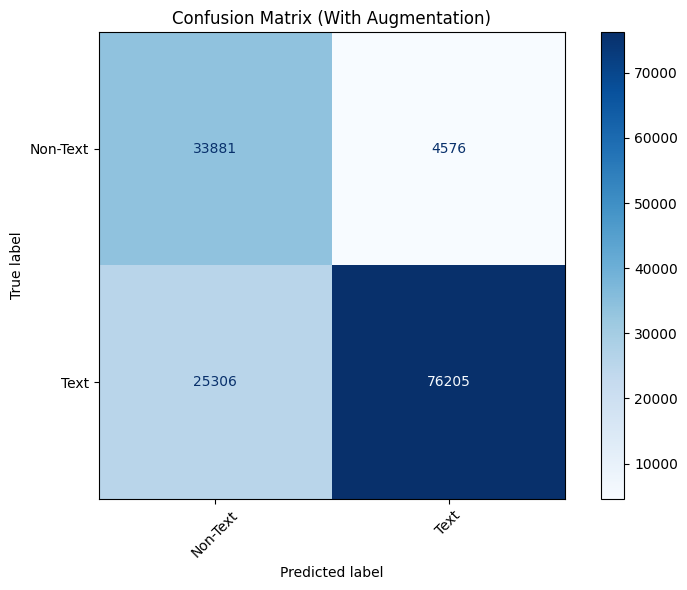

In [11]:
if test_aug_only_files:
    print("=== Запуск тестування на файлах з аугментацією ===")
    test_aug_dataset = StrokeGraphDataset_class.StrokeGraphDataset(BATCHES_DIRECTORY, test_files_with_aug)
    test_aug_loader = DataLoader(test_aug_dataset, batch_size=batch_size, shuffle=False)

    evaluate_and_plot(model, test_aug_loader, device, class_names, title_prefix="With Augmentation")
else:
    print("Аугментовані файли не знайдені у директорії батчів. Цей крок пропущено.")
    